Image thresholding is an image processing technique that simplifies an image by converting each pixel's intensity to one of two values, typically black or white, based on a chosen threshold

In [1]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
img = cv2.imread('../rainbow.jpg', 0)

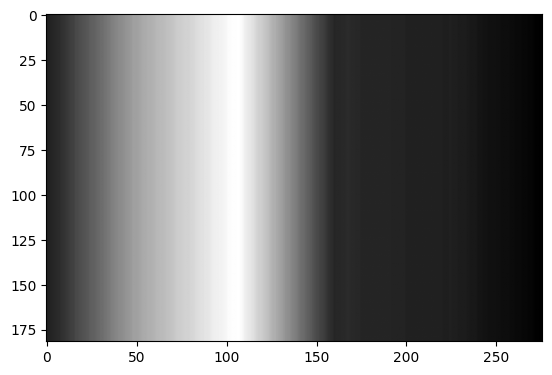

In [3]:
plt.imshow(img, cmap='gray')

# Types of thresholds include:
- Absolute Threshold (minimum stimulus to detect), 
- Difference Threshold (minimum detectable change between stimuli),
- Recognition Threshold (minimum stimulus to identify a stimulus)
- Terminal Threshold

- Pain Threshold
- Adaptation Threshold
- Carpet Dividers/Door Thresholds
- Anaerobic Threshold

In [4]:
img.max()

np.uint8(220)

# OpenCV Threshold Types

## Basic Threshold Types:

**THRESH_BINARY:**
```
dst(x, y) = {
    maxval     if src(x,y) > thresh
    0          otherwise
}
```

**THRESH_BINARY_INV:**
```
dst(x, y) = {
    0          if src(x,y) > thresh
    maxval     otherwise
}
```

**THRESH_TRUNC:**
```
dst(x, y) = {
    threshold  if src(x,y) > thresh
    src(x, y)  otherwise 
}
```

**THRESH_TOZERO:**
```
dst(x, y) = {
    src(x, y)  if src(x,y) > thresh
    0          otherwise
}
```

**THRESH_TOZERO_INV:**
```
dst(x, y) = {
    0          if src(x,y) > thresh
    src(x, y)  otherwise
}
```

## Adaptive Threshold Types:

**ADAPTIVE_THRESH_MEAN_C:**
- Uses mean of neighborhood area
- Good for uniform lighting

**ADAPTIVE_THRESH_GAUSSIAN_C:**
- Uses weighted sum of neighborhood values
- Weights are Gaussian window
- Better for varying lighting

## Otsu's Method:

**THRESH_OTSU:**
- Automatically determines optimal threshold value
- Works best with bimodal histograms
- Often combined with other methods: `cv2.THRESH_BINARY + cv2.THRESH_OTSU`

## Triangle Method:

**THRESH_TRIANGLE:**
- Uses triangle algorithm to find threshold
- Good for images with clear peaks in histogram

In [5]:
ret, theresh1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

In [6]:
ret 

127.0

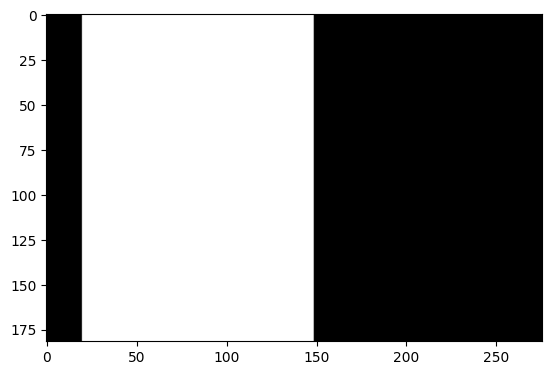

In [7]:
plt.imshow(theresh1, cmap='gray')

In [8]:
img = cv2.imread('../crossword.png')

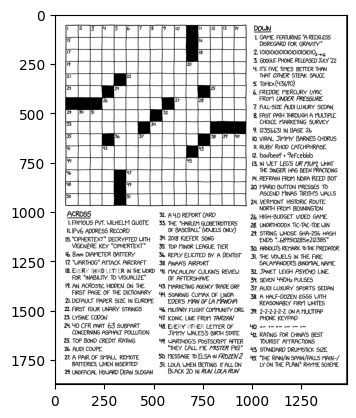

In [9]:
plt.imshow(img, cmap='gray')

In [10]:
def show_pic(img):
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

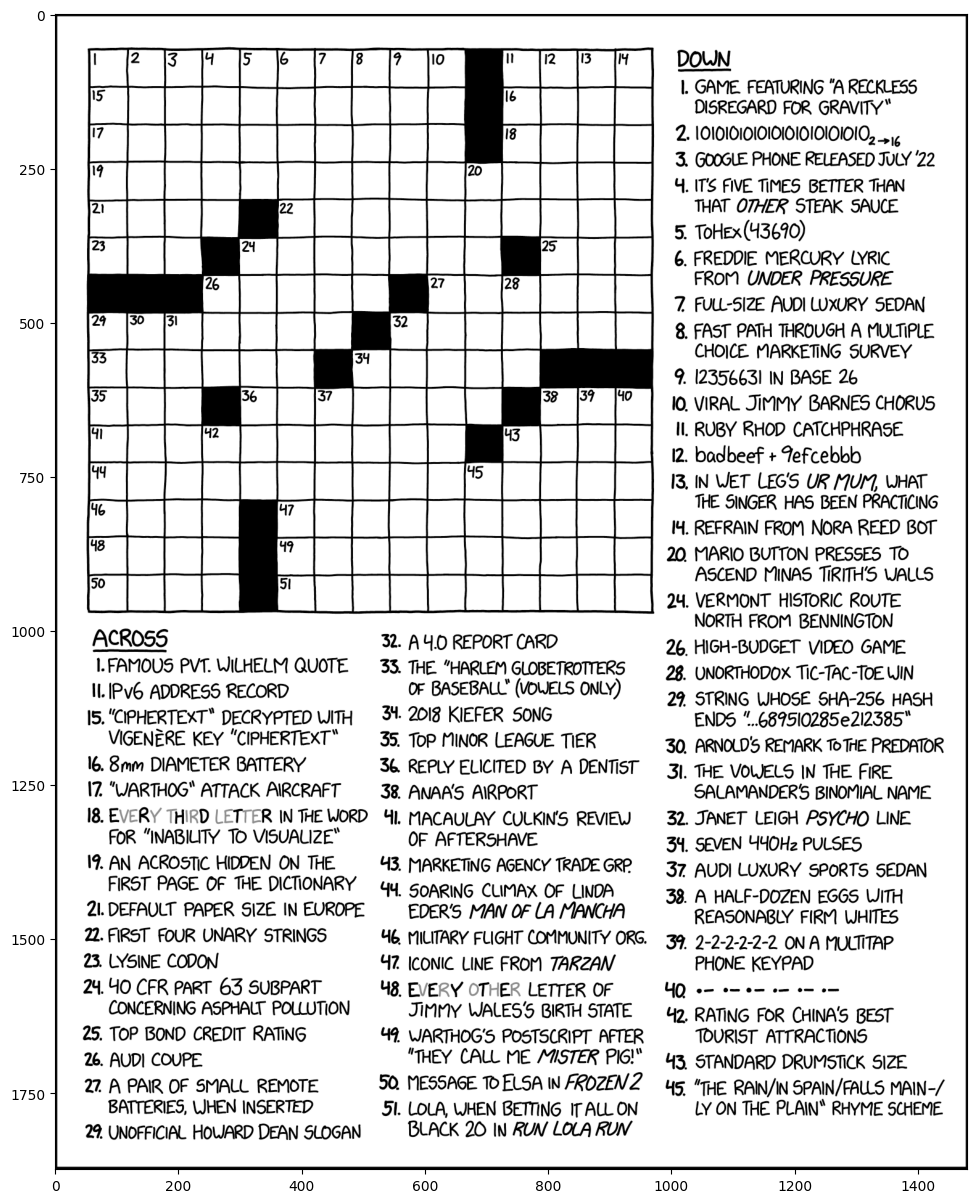

In [11]:
show_pic(img)

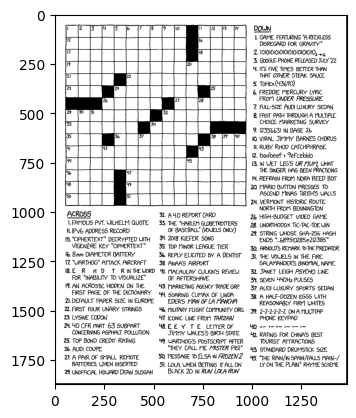

In [12]:
ret, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
plt.imshow(th1, cmap='gray')

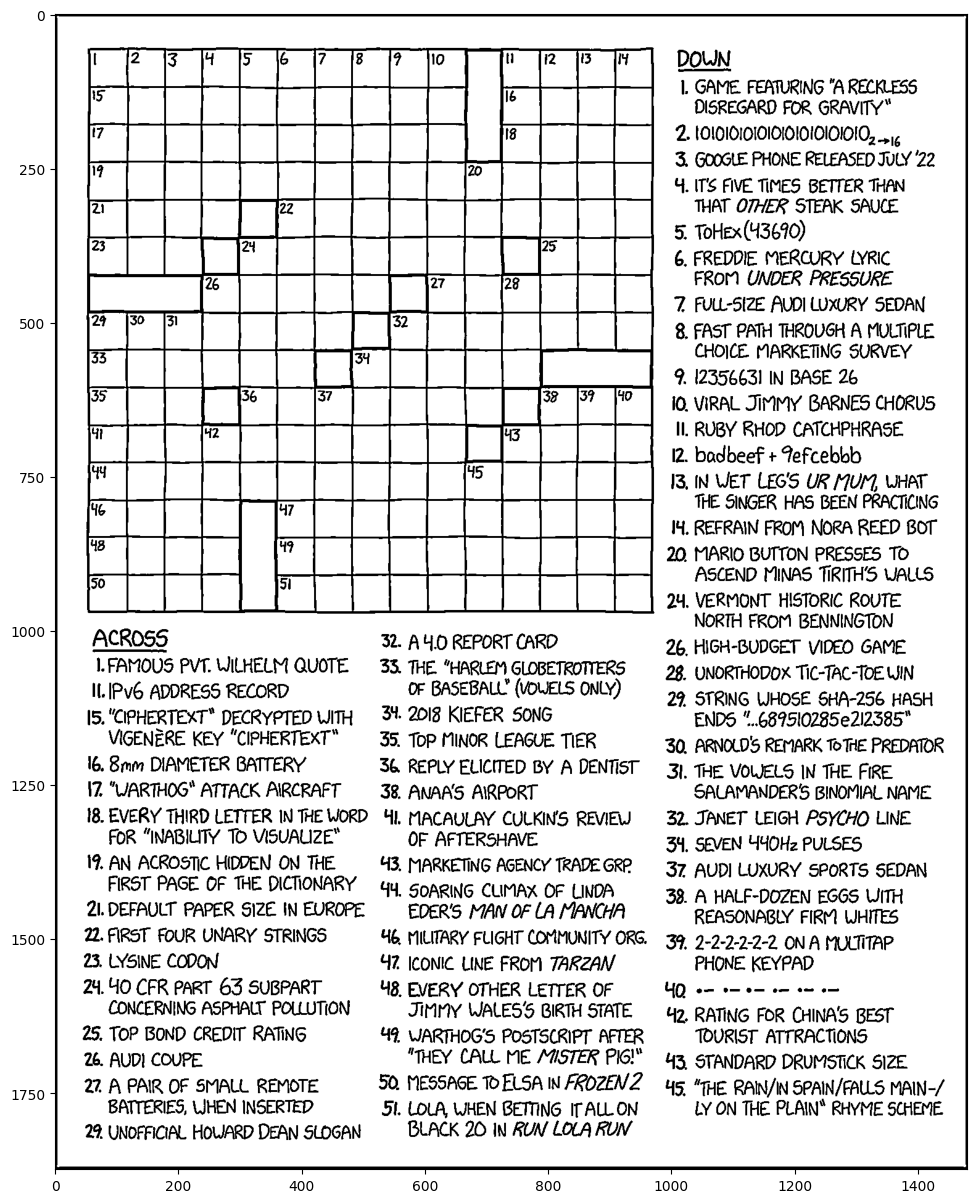

In [13]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
th2 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                            cv2.THRESH_BINARY, 11, 8)
show_pic(th2)

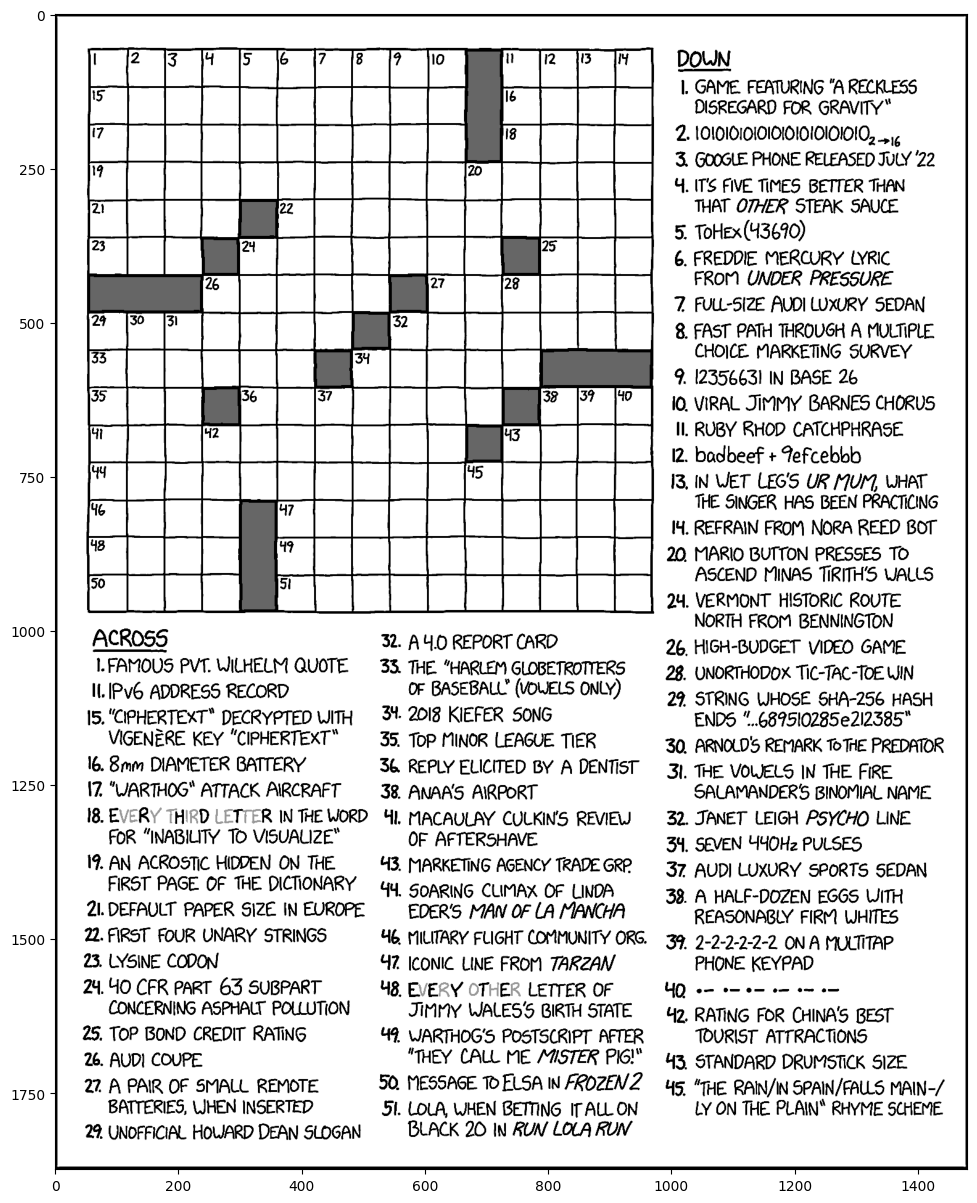

In [14]:
# Step 1: Resize th2 to match th1's shape
th2_resized = cv2.resize(th2, (th1.shape[1], th1.shape[0]))

# Step 2: If one is grayscale and the other is color, convert grayscale to BGR
if len(th1.shape) == 3 and len(th2_resized.shape) == 2:
    th2_resized = cv2.cvtColor(th2_resized, cv2.COLOR_GRAY2BGR)
elif len(th1.shape) == 2 and len(th2_resized.shape) == 3:
    th1 = cv2.cvtColor(th1, cv2.COLOR_GRAY2BGR)

# Step 3: Blend
blended = cv2.addWeighted(th1, 0.6, th2_resized, 0.4, 0)
show_pic(blended)